
# ⚡ Reserved Capacity Optimisation — Czech Industrial Plant
### Real data · PuLP LP · January–May 2025 · BESS 5.5 MWh · Solar PV 450 kW AC

---

**What this notebook does:**

> For each month (January–May) we have a typical weekly consumption, solar PV output,
> and OTE price profile (672 intervals × 15 min = 7 days). The LP solver **simultaneously
> optimises** the reserved capacity `P_rez` and the BESS dispatch to **minimise total monthly costs**.

---

| Sekce | Obsah |
|-------|-------|
| **1** | Mathematical model — variables, objective function, constraints |
| **2** | Loading data from Excel (real profiles) |
| **3** | LP model (PuLP) — definition and solution for each month |
| **4** | Results — tables and comparison with Excel benchmark |
| **5** | Visualisation — seaborn dashboards for each month |
| **6** | Monthly comparison — savings analysis and PV/BESS impact |



## 1. Mathematical Model

### 1.1 Decision Variables

| Symbol | Unit | Description |
|--------|----------|-------|
| $P_{rez}$ | kW | **Reserved capacity** — main decision variable |
| $P_{peak}$ | kW | Actual weekly peak grid draw |
| $P_{grid,t}$ | kW | Grid draw in interval $t$ |
| $P_{ch,t}$ | kW | BESS charging power in interval $t$ |
| $P_{dch,t}$ | kW | BESS discharging power in interval $t$ |

### 1.2 Parameters (constants)

| Symbol | Value | Unit | Description |
|--------|---------|----------|-------|
| $E_{BESS}$ | 5 500 | kWh | Battery capacity |
| $P_{max}$ | 2 750 | kW | Max charge/discharge (C-rate = 0.5) |
| $\eta_{ch}, \eta_{dch}$ | 0.95 | — | Charge / discharge efficiency |
| $SOC_{min}, SOC_{max}$ | 0.1 / 0.9 | pu | State of charge limits |
| $c_{rez}$ | 350 | CZK/kW/month | Reserved capacity tariff |
| $c_{pen}$ | 300 × 2.5 | CZK/kW/month | Penalty for exceeding $P_{rez}$ |
| $c_{dist}$ | 87 | CZK/MWh | Distribution energy charge |
| $c_{deg}$ | 80 | CZK/MWh | BESS degradation cost |
| $\Delta t$ | 0.25 | h | Interval length (15 min) |
| $T$ | 672 | — | Number of intervals (7 days) |

### 1.3 Objective Function

We minimise **total weekly costs** (scaled to monthly via `weekly_factor`):

$$\min \underbrace{c_{rez} \cdot P_{rez} \cdot f_w}_{\text{rezervace}} + \sum_{t=0}^{T-1} \left[ \underbrace{\frac{(\lambda_t + c_{dist}) \cdot P_{grid,t} \cdot \Delta t}{1000}}_{\text{energie ze sítě}} + \underbrace{\frac{c_{deg} \cdot (P_{ch,t} + P_{dch,t}) \cdot \Delta t}{1000}}_{\text{degradace BESS}} \right]$$

where $f_w = \frac{7}{30.44}$ is the weekly-to-monthly scaling factor.

> **Note:** The penalty for exceeding `P_rez` is modelled as a hard constraint
> $P_{grid,t} \leq P_{rez}$ — the solver cannot violate it. Alternative: soft constraint.

### 1.4 Constraints

$$\text{(C1 — power balance)} \quad P_{grid,t} + P_{dch,t} - P_{ch,t} = \underbrace{L_t - G_t}_{net_t} \qquad \forall t$$

$$\text{(C2 — reservation)} \quad P_{grid,t} \leq P_{rez} \qquad \forall t$$

$$\text{(C3 — SOC recurrence)} \quad SOC_{t+1} = SOC_t + \eta_{ch} \cdot P_{ch,t} \cdot \Delta t - \frac{P_{dch,t}}{\eta_{dch}} \cdot \Delta t$$

$$\text{(C4 — SOC limits)} \quad SOC_{min} \cdot E_{BESS} \leq SOC_t \leq SOC_{max} \cdot E_{BESS} \qquad \forall t$$

$$\text{(C5 — power limits)} \quad 0 \leq P_{ch,t} \leq P_{max}, \quad 0 \leq P_{dch,t} \leq P_{max} \qquad \forall t$$

$$\text{(C6 — daily SOC reset)} \quad SOC_{d \cdot 96} = 0.5 \cdot E_{BESS} \qquad \forall d \in \{0,1,\ldots,6\}$$

$$\text{(C7 — P\_rez range)} \quad P_{rez,min} \leq P_{rez} \leq P_{grid,max}$$

> **C6** is critical: the BESS resets to 50 % every day — prevents the solver from
> "consuming" Monday's charge without returning it by end of week.


## 2. Loading Data

In [1]:
# ── Libraries ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pulp
import warnings
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:,.2f}".format)

print("Library versions:")
print(f"  numpy   {np.__version__}")
print(f"  pandas  {pd.__version__}")
print(f"  pulp    {pulp.__version__}")
print(f"  seaborn {sns.__version__}")


Library versions:
  numpy   2.4.2
  pandas  3.0.1
  pulp    3.3.0
  seaborn 0.13.2


### 2.1 Parameters from the Assumptions Sheet

In [2]:
# ── All parameters from Guzu_Real_fixed_50.xlsx / Assumptions ──────────────
# (Written inline — for clarity and reproducibility)

BESS_cap   = 5_500      # kWh  — battery capacity
P_max      = 2_750      # kW   — max charge = max discharge (C-rate 0.5)
eta_ch     = 0.95       # —    — charge efficiency
eta_dch    = 0.95       # —    — discharge efficiency
SOC_min_pu = 0.10       # pu   — minimum SoC
SOC_max_pu = 0.90       # pu   — maximum SoC
SOC_init_pu= 0.50       # pu   — initial SoC (each day)

SOC_min    = SOC_min_pu * BESS_cap   # kWh = 550
SOC_max    = SOC_max_pu * BESS_cap   # kWh = 4950
SOC_init   = SOC_init_pu * BESS_cap  # kWh = 2750

FVE_dc_kw  = 500        # kW   — peak DC výkon FVE
FVE_ac_lim = 450        # kW   — limit střídače AC
FVE_pr     = 0.82       # pu   — performance ratio

P_grid_max = 4_000      # kW   — hard grid connection limit
dt         = 0.25       # h    — 15-min step
T          = 672        # —    — 7 days × 96 intervals

c_rez      = 350        # CZK/kW/month — reservation tariff
c_pen_unit = 300        # CZK/kW/month — overrun penalty
c_pen_mult = 2.5        # —             — penalty multiplier
c_dist     = 87         # CZK/MWh — distribution charge
c_deg      = 80         # CZK/MWh — BESS degradation cost

P_rez_min  = 500        # kW   — contractual minimum
P_rez_max  = P_grid_max # kW

days_in_month = 30.44   # average
weekly_factor = 7 / days_in_month   # weekly → monthly scaling factor

# Excel benchmark (from Assumptions sheet — filled values)
EXCEL_BENCHMARK = {
    "Jan": 1810.97,
    "Feb": 1955.52,
    "Mar": 2364.00,
    "Apr": None,
    "May": None,
}

print("✓ Parameters loaded")
print(f"  BESS: {BESS_cap} kWh  |  P_max: {P_max} kW")
print(f"  SOC: [{SOC_min:.0f}, {SOC_max:.0f}] kWh  |  init: {SOC_init:.0f} kWh")
print(f"  c_rez: {c_rez} CZK/kW/měs  |  c_dist: {c_dist} CZK/MWh")
print(f"  T: {T} intervalů = {T*dt:.0f} h = 7 dní")


✓ Parameters loaded
  BESS: 5500 kWh  |  P_max: 2750 kW
  SOC: [550, 4950] kWh  |  init: 2750 kWh
  c_rez: 350 CZK/kW/měs  |  c_dist: 87 CZK/MWh
  T: 672 intervalů = 168 h = 7 dní


### 2.2 Loading Weekly Profiles from Excel

In [3]:
PROFILES_FILE = "Profiles_15min_v2.xlsx"

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May"]
SHEET_MAP = {
    "Jan": "TypWeek_Jan",
    "Feb": "TypWeek_Feb",
    "Mar": "TypWeek_Mar",
    "Apr": "TypWeek_Apr",
    "May": "TypWeek_May",
}

def load_week_profile(month: str) -> pd.DataFrame:
    """
    Load the typical weekly profile from a TypWeek_* sheet.

    Returns a DataFrame with 672 rows and columns:
      time_str, dow, interval,
      load_kw, fve_kw, ote_czk_mwh, net_kw

    Input data is in kWh/interval → convert to kW: / dt (÷ 0.25)
    """
    sheet = SHEET_MAP[month]
    # Row 0 = title, row 1 = headers, data from row 2
    df_raw = pd.read_excel(
        PROFILES_FILE, sheet_name=sheet, header=None, skiprows=2
    )
    df_raw.columns = ["day_name", "dow", "interval", "time_str",
                      "consumption_kwh", "fve_kwh", "ote_czk_mwh"]

    # kWh/15min → kW
    df = pd.DataFrame({
        "time_str":     df_raw["time_str"].astype(str),
        "dow":          df_raw["dow"].astype(int),
        "interval":     df_raw["interval"].astype(int),
        "load_kw":      df_raw["consumption_kwh"] / dt,    # kWh → kW
        "fve_kw":       (df_raw["fve_kwh"] / dt).clip(upper=450),  # kWh→kW, capped at AC inverter limit
        "ote_czk_mwh":  df_raw["ote_czk_mwh"].astype(float),
    })

    # Net demand (positive = draw, negative = PV surplus)
    df["net_kw"] = df["load_kw"] - df["fve_kw"]

    # Time index within the week (0..671)
    df.index = range(len(df))
    return df

# Načti všechny měsíce
profiles = {}
for m in MONTHS:
    profiles[m] = load_week_profile(m)
    print(f"  {m}: {len(profiles[m])} intervalů  |  "
          f"load max={profiles[m]['load_kw'].max():,.0f} kW  "
          f"avg={profiles[m]['load_kw'].mean():,.0f} kW  |  "
          f"FVE max={profiles[m]['fve_kw'].max():,.1f} kW  |  "
          f"OTE avg={profiles[m]['ote_czk_mwh'].mean():,.0f} CZK/MWh")

print("\n✓ All profiles loaded")


  Jan: 672 intervalů  |  load max=2,371 kW  avg=1,482 kW  |  FVE max=417.7 kW  |  OTE avg=3,227 CZK/MWh
  Feb: 672 intervalů  |  load max=2,628 kW  avg=1,712 kW  |  FVE max=450.0 kW  |  OTE avg=3,327 CZK/MWh


  Mar: 672 intervalů  |  load max=2,291 kW  avg=1,573 kW  |  FVE max=450.0 kW  |  OTE avg=2,518 CZK/MWh


  Apr: 672 intervalů  |  load max=2,276 kW  avg=1,472 kW  |  FVE max=450.0 kW  |  OTE avg=1,972 CZK/MWh
  May: 672 intervalů  |  load max=2,332 kW  avg=1,429 kW  |  FVE max=450.0 kW  |  OTE avg=1,848 CZK/MWh

✓ All profiles loaded


### 2.3 Input Data Overview

In [4]:
# Comparison table of input data by month
summary_rows = []
for m in MONTHS:
    df = profiles[m]
    summary_rows.append({
        "Month":            m,
        "Consumption avg (kW)": f"{df['load_kw'].mean():,.1f}",
        "Consumption max (kW)": f"{df['load_kw'].max():,.1f}",
        "FVE avg (kW)":      f"{df['fve_kw'].mean():,.1f}",
        "FVE max (kW)":      f"{df['fve_kw'].max():,.1f}",
        "Net avg (kW)":    f"{df['net_kw'].mean():,.1f}",
        "Net max (kW)":    f"{df['net_kw'].max():,.1f}",
        "OTE avg (CZK/MWh)": f"{df['ote_czk_mwh'].mean():,.0f}",
        "OTE max (CZK/MWh)": f"{df['ote_czk_mwh'].max():,.0f}",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Month")
print("Input profiles — weekly statistics:")
print(summary_df.to_string())


Input profiles — weekly statistics:


      Consumption avg (kW) Consumption max (kW) FVE avg (kW) FVE max (kW) Net avg (kW) Net max (kW) OTE avg (CZK/MWh) OTE max (CZK/MWh)
Month                                                                                                                                  
Jan                1,482.0              2,371.1         56.5        417.7      1,425.5      2,337.7             3,227             6,369
Feb                1,711.6              2,628.4        119.7        450.0      1,591.9      2,564.7             3,327             5,215
Mar                1,573.3              2,291.2        158.9        450.0      1,414.4      2,105.1             2,518             4,745
Apr                1,472.4              2,275.8        194.5        450.0      1,277.9      2,208.5             1,972             4,501
May                1,428.7              2,332.1        211.1        450.0      1,217.6      2,202.5             1,848             5,129



## 3. LP Model (PuLP)

### 3.1 Model Definition

The `solve_week()` function takes one month's profiles and returns the optimal `P_rez`
and the full dispatch plan. Comments reference constraints C1–C7 from the model above.


In [5]:
def solve_week(df: pd.DataFrame, month_name: str = "") -> dict:
    """
    Weekly dispatch LP optimisation.

    Inputs:
      df — DataFrame with columns: load_kw, fve_kw, net_kw, ote_czk_mwh
           672 rows (7 days × 96 intervals of 15 min each)

    Output: dict with optimal values and full dispatch profile
    """
    T_local = len(df)  # = 672
    OTE  = df["ote_czk_mwh"].values.astype(float)
    net  = df["net_kw"].values.astype(float)       # L - G [kW]
    load = df["load_kw"].values.astype(float)
    fve  = df["fve_kw"].values.astype(float)

    # ── Create LP problem ──────────────────────────────────────────────────
    prob = pulp.LpProblem(f"WeeklyDispatch_{month_name}", pulp.LpMinimize)

    # ── Decision variables ────────────────────────────────────────────────

    # P_rez — reserved capacity [kW] (C7: bounded)
    P_rez = pulp.LpVariable("P_rez", lowBound=P_rez_min, upBound=P_rez_max)

    # P_grid[t] — grid draw in each interval [kW]
    P_grid = [pulp.LpVariable(f"Pg_{t}", 0, P_grid_max) for t in range(T_local)]

    # P_ch[t], P_dch[t] — BESS charge / discharge [kW]
    P_ch  = [pulp.LpVariable(f"Pc_{t}", 0, P_max) for t in range(T_local)]
    P_dch = [pulp.LpVariable(f"Pd_{t}", 0, P_max) for t in range(T_local)]

    # ── SOC recurrence ─────────────────────────────────────────────────────
    # SOC is a linear expression (not a DV) — solver sees it through P_ch, P_dch
    # C6: daily reset — each day starts from SOC_init
    SOC = [None] * (T_local + 1)

    for d in range(7):               # 7 dní
        t0 = d * 96                  # začátek dne (interval 0, 96, 192 ...)
        SOC[t0] = SOC_init           # C6: reset na 50 % kapacity

        for t in range(t0, t0 + 96):
            # C3: SOC_{t+1} = SOC_t + eta_ch * P_ch * dt - P_dch/eta_dch * dt
            SOC[t + 1] = (SOC[t]
                          + eta_ch  * P_ch[t]  * dt
                          - (1 / eta_dch) * P_dch[t] * dt)

    # ── Objective function ─────────────────────────────────────────────────
    # Reservation cost (monthly, scaled via weekly_factor)
    cost_rez = c_rez * P_rez * weekly_factor

    # Grid energy cost (OTE + distribution) + BESS degradation
    cost_ops = pulp.lpSum(
        (OTE[t] + c_dist) * P_grid[t] * dt / 1000          # CZK (energy)
        + c_deg * (P_ch[t] + P_dch[t]) * dt / 1000         # CZK (degradation)
        for t in range(T_local)
    )

    prob += cost_rez + cost_ops   # minimise total

    # ── Constraints ───────────────────────────────────────────────────────
    for t in range(T_local):
        # C1: power balance — grid + discharge − charge = net demand
        prob += P_grid[t] + P_dch[t] - P_ch[t] == net[t]

        # C2: P_grid must not exceed reserved capacity (hard constraint = peak shaving)
        prob += P_grid[t] <= P_rez

        # C4: SOC limits
        prob += SOC[t + 1] >= SOC_min
        prob += SOC[t + 1] <= SOC_max

    # C7 enforced via bounds on P_rez (lowBound, upBound above)

    # ── Solve ──────────────────────────────────────────────────────────────
    solver = pulp.GLPK(msg=False)
    status = prob.solve(solver)

    if pulp.LpStatus[status] not in ("Optimal", "Feasible"):
        return {"status": pulp.LpStatus[status], "month": month_name}

    # ── Extract results ────────────────────────────────────────────────────
    p_rez_val  = pulp.value(P_rez)
    total_cost = pulp.value(prob.objective)

    pg_arr  = np.array([pulp.value(P_grid[t]) for t in range(T_local)])
    pch_arr = np.array([pulp.value(P_ch[t])   for t in range(T_local)])
    pdc_arr = np.array([pulp.value(P_dch[t])  for t in range(T_local)])

    # Reconstruct SOC day by day
    soc_arr = np.zeros(T_local)
    for d in range(7):
        t0 = d * 96
        soc_d = SOC_init
        for t in range(t0, t0 + 96):
            soc_arr[t] = soc_d
            soc_d = (soc_d
                     + eta_ch * pch_arr[t] * dt
                     - pdc_arr[t] / eta_dch * dt)

    # Cost breakdown by component
    cost_rez_val  = c_rez * p_rez_val * weekly_factor
    cost_ene_val  = float(np.sum((OTE + c_dist) * pg_arr * dt / 1000))
    cost_deg_val  = float(np.sum(c_deg * (pch_arr + pdc_arr) * dt / 1000))

    return {
        "month":        month_name,
        "status":       pulp.LpStatus[status],
        "P_rez_kw":     p_rez_val,
        "total_czk":    total_cost,
        "cost_rez":     cost_rez_val,
        "cost_energy":  cost_ene_val,
        "cost_deg":     cost_deg_val,
        "monthly_czk":  total_cost / weekly_factor,   # scaled to full month
        # Time series (arrays)
        "P_grid":  pg_arr,
        "P_ch":    pch_arr,
        "P_dch":   pdc_arr,
        "SOC":     soc_arr,
        "load":    load,
        "fve":     fve,
        "net":     net,
        "OTE":     OTE,
        "df":      df,
    }

print("✓ Function solve_week() defined")


✓ Function solve_week() defined


### 3.2 Solving for Each Month

In [6]:
results = {}

print(f"{'Měsíc':>6}  {'Status':>8}  {'P_rez (kW)':>12}  {'Týden (CZK)':>13}  "
      f"{'Měsíc est. (CZK)':>18}  {'Excel bench':>12}  {'Δ (kW)':>8}")
print("─" * 90)

for m in MONTHS:
    res = solve_week(profiles[m], month_name=m)
    results[m] = res

    bench = EXCEL_BENCHMARK.get(m)
    delta = f"{res['P_rez_kw'] - bench:+.1f}" if bench else "  n/a"

    print(f"  {m:>4}  {res['status']:>8}  {res['P_rez_kw']:>12,.1f}  "
          f"{res['total_czk']:>13,.0f}  {res['monthly_czk']:>18,.0f}  "
          f"{str(bench or '—'):>12}  {delta:>8}")

print("\n✓ All months optimised")
print("  Δ = our result minus Excel benchmark (+ = higher reservation)")


 Měsíc    Status    P_rez (kW)    Týden (CZK)    Měsíc est. (CZK)   Excel bench    Δ (kW)
──────────────────────────────────────────────────────────────────────────────────────────


   Jan   Optimal       1,732.0        865,675           3,764,449       1810.97     -79.0


   Feb   Optimal       1,818.3        995,036           4,326,984       1955.52    -137.2


   Mar   Optimal       1,740.6        676,522           2,941,905        2364.0    -623.4


   Apr   Optimal       1,683.6        508,600           2,211,685             —       n/a


   May   Optimal       1,584.8        458,772           1,995,002             —       n/a

✓ All months optimised
  Δ = our result minus Excel benchmark (+ = higher reservation)


### 3.3 Detailed Results Table

In [7]:
rows = []
for m in MONTHS:
    r = results[m]
    bench = EXCEL_BENCHMARK.get(m)
    rows.append({
        "Month":              m,
        "P_rez* (kW)":        f"{r['P_rez_kw']:,.1f}",
        "Excel bench (kW)":   f"{bench:,.1f}" if bench else "—",
        "Reservation cost (CZK)": f"{r['cost_rez']:,.0f}",
        "Energy cost (CZK)":   f"{r['cost_energy']:,.0f}",
        "BESS degradation (CZK)": f"{r['cost_deg']:,.0f}",
        "Week total (CZK)":   f"{r['total_czk']:,.0f}",
        "Month est. (CZK)":     f"{r['monthly_czk']:,.0f}",
        "P_grid max (kW)":       f"{r['P_grid'].max():,.1f}",
        "BESS throughput (MWh)":    f"{(r['P_ch'].sum()*dt/1000):,.2f}",
    })

res_df = pd.DataFrame(rows).set_index("Month")
print("Optimisation results — January to May 2025:")
print(res_df.to_string())

# Annual projection (5 months → extrapolation)
total_monthly_avg = np.mean([results[m]["monthly_czk"] for m in MONTHS])
print(f"\nPrůměrný měsíční náklad (Leden–Květen): {total_monthly_avg:,.0f} CZK")
print(f"Annual estimate (×12):               {total_monthly_avg*12:,.0f} CZK")


Optimisation results — January to May 2025:
      P_rez* (kW) Excel bench (kW) Reservation cost (CZK) Energy cost (CZK) BESS degradation (CZK) Week total (CZK) Month est. (CZK) P_grid max (kW) BESS throughput (MWh)
Month                                                                                                                                                                     
Jan       1,732.0          1,811.0                139,402           722,338                  3,935          865,675        3,764,449         1,732.0                 16.99
Feb       1,818.3          1,955.5                146,349           844,450                  4,237          995,036        4,326,984         1,818.3                 18.84
Mar       1,740.6          2,364.0                140,098           530,636                  5,789          676,522        2,941,905         1,740.6                 29.09
Apr       1,683.6                —                135,508           366,754                  6,339   

## 4. Results Visualisation

In [8]:
# ── Global seaborn theme ──────────────────────────────────────────────────
D = {
    "bg":     "#0d1117",   "panel":  "#161b22",   "grid":   "#30363d",
    "text":   "#e6edf3",   "sub":    "#8b949e",
    "load":   "#ef9a9a",   "fve":    "#ffd54f",   "net":    "#80cbc4",
    "grid_p": "#4fc3f7",   "bess":   "#a78bfa",   "soc":    "#69db7c",
    "ote":    "#fb923c",   "rez":    "#f472b6",    "ch":     "#34d399",
    "dch":    "#f87171",
}

sns.set_theme(style="darkgrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor":   D["bg"],    "axes.facecolor":   D["panel"],
    "axes.edgecolor":     D["grid"],  "axes.labelcolor":  D["text"],
    "axes.titlecolor":    D["text"],  "xtick.color":      D["sub"],
    "ytick.color":        D["sub"],   "grid.color":       D["grid"],
    "grid.linewidth":     0.5,        "text.color":       D["text"],
    "legend.facecolor":   D["panel"], "legend.edgecolor": D["grid"],
    "legend.labelcolor":  D["text"],  "axes.spines.top":  False,
    "axes.spines.right":  False,
})

# Helper functions
DAYS = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

def day_ticks(ax, T_local=672):
    """Add vertical day separators and day labels to x-axis."""
    for d in range(7):
        ax.axvline(d * 96, color=D["grid"], linewidth=1.0, alpha=0.7)
    ax.set_xticks([d * 96 + 48 for d in range(7)])
    ax.set_xticklabels(DAYS, fontsize=9)

def style(ax, title, ylabel, xlabel=""):
    ax.set_title(title, fontweight="bold", fontsize=10, pad=8)
    ax.set_ylabel(ylabel, fontsize=9)
    if xlabel: ax.set_xlabel(xlabel, fontsize=9)

print("✓ Visual theme set")


✓ Visual theme set


### 4.1 Weekly Dispatch Dashboard — Each Month

  ✓ Uloženo: dispatch_Jan.png


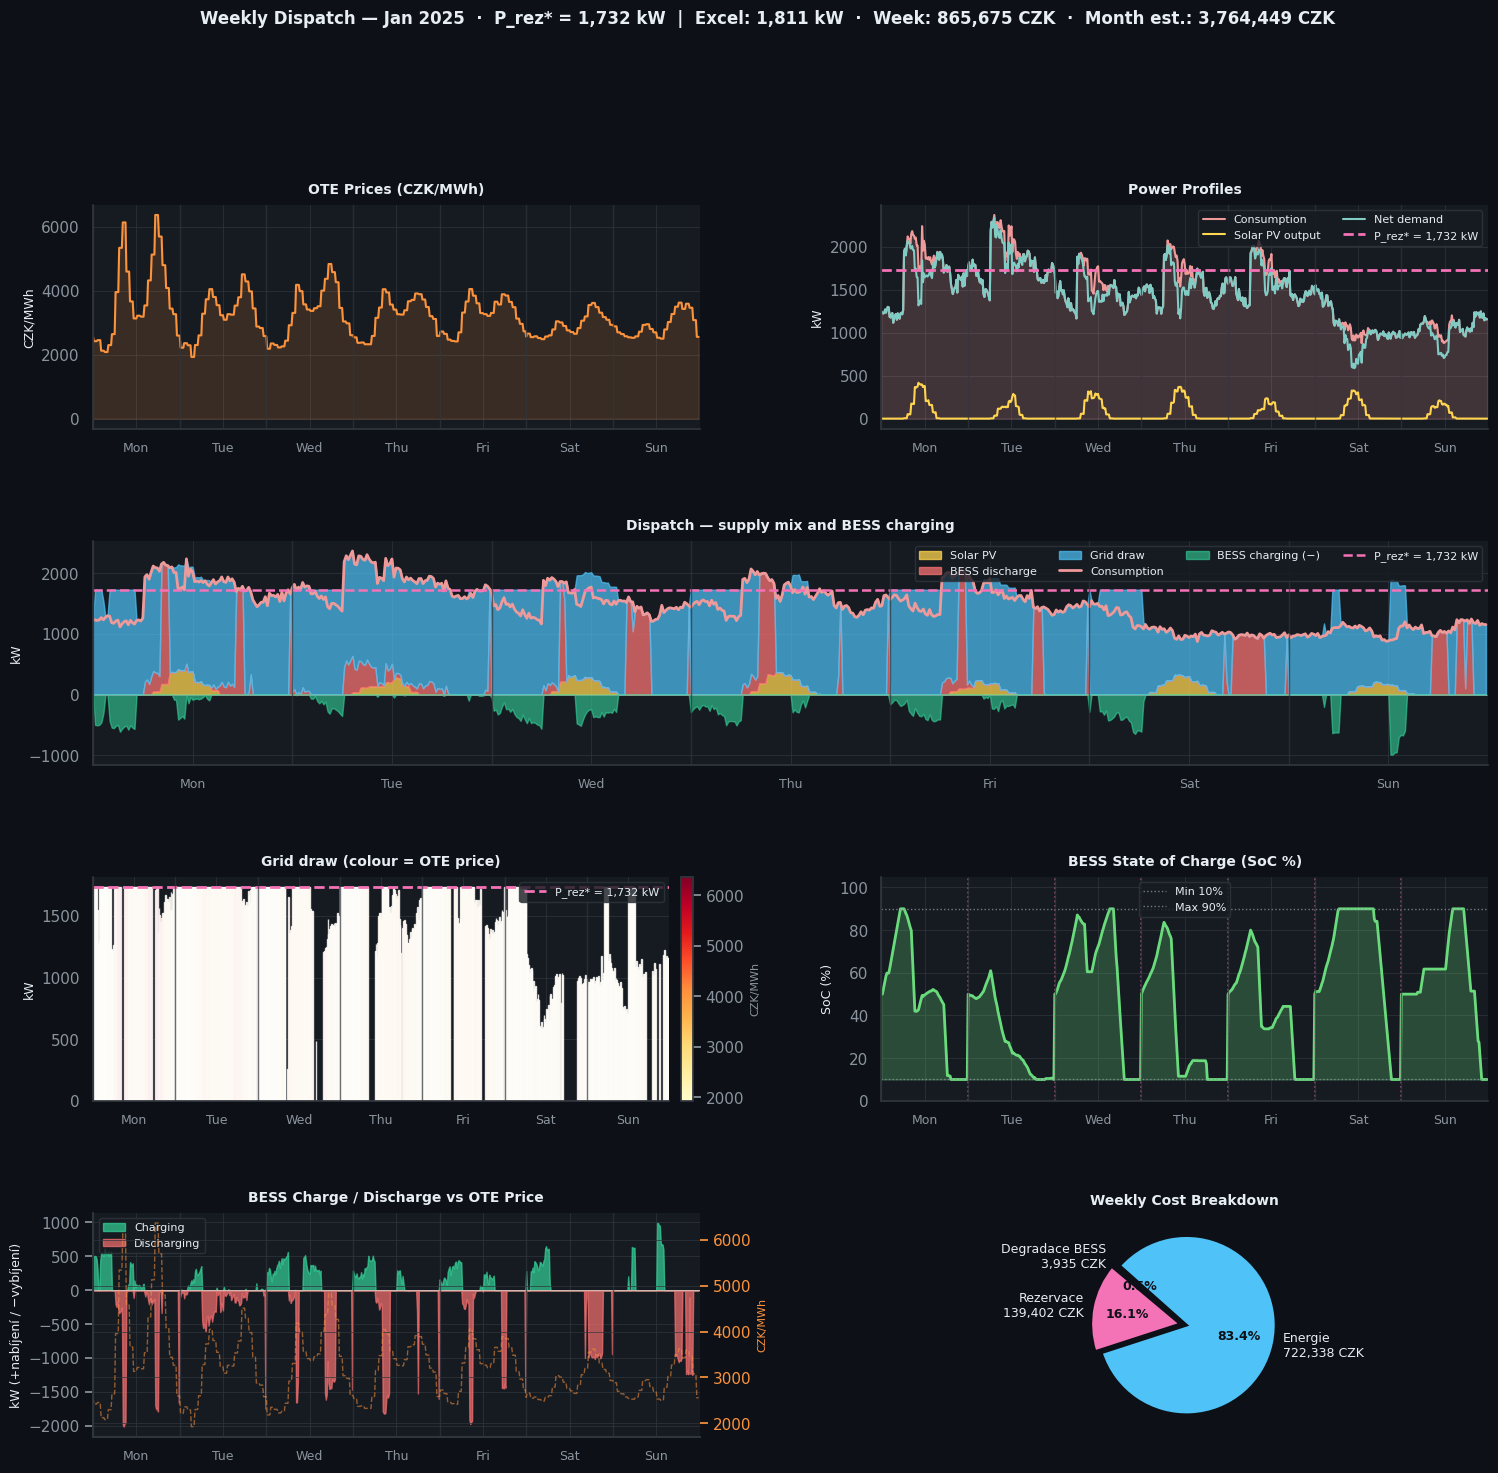

  ✓ Uloženo: dispatch_Feb.png


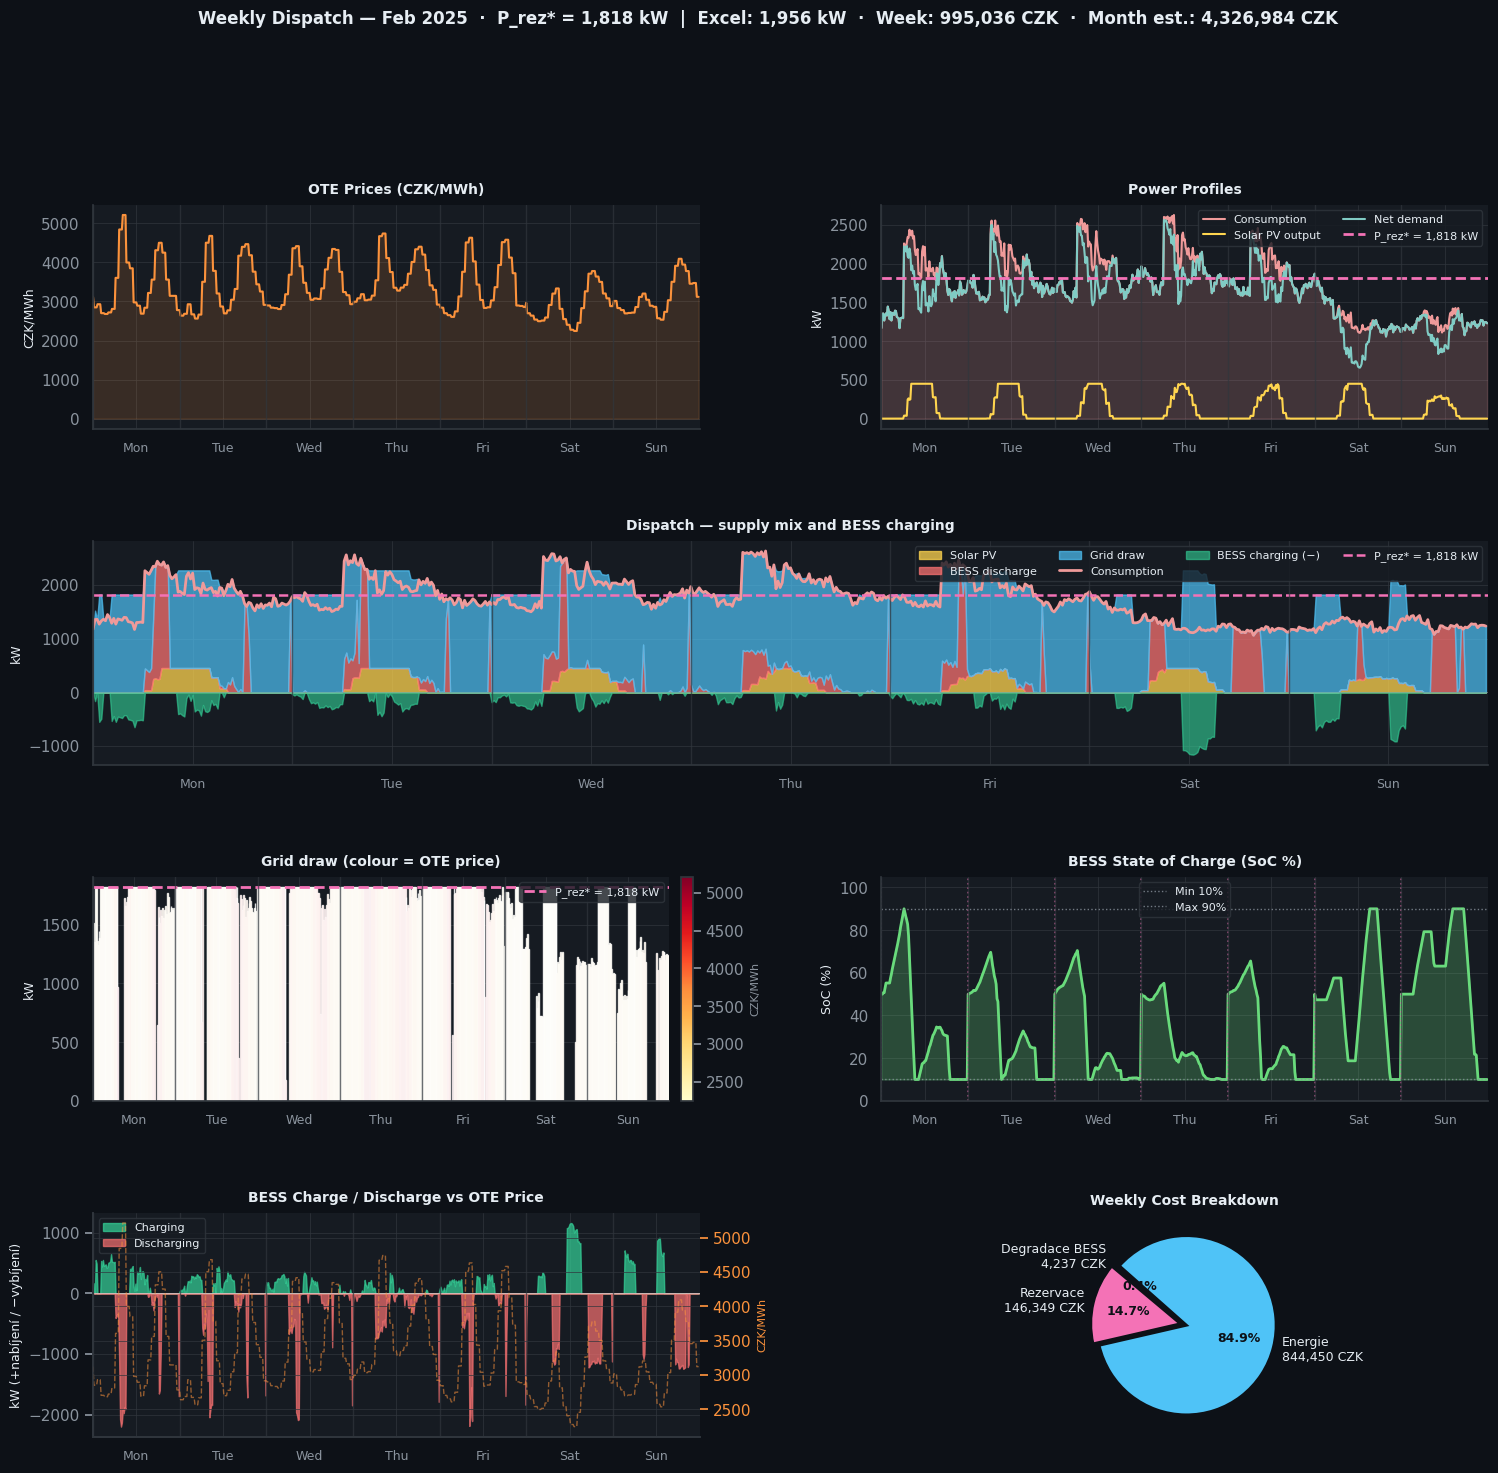

  ✓ Uloženo: dispatch_Mar.png


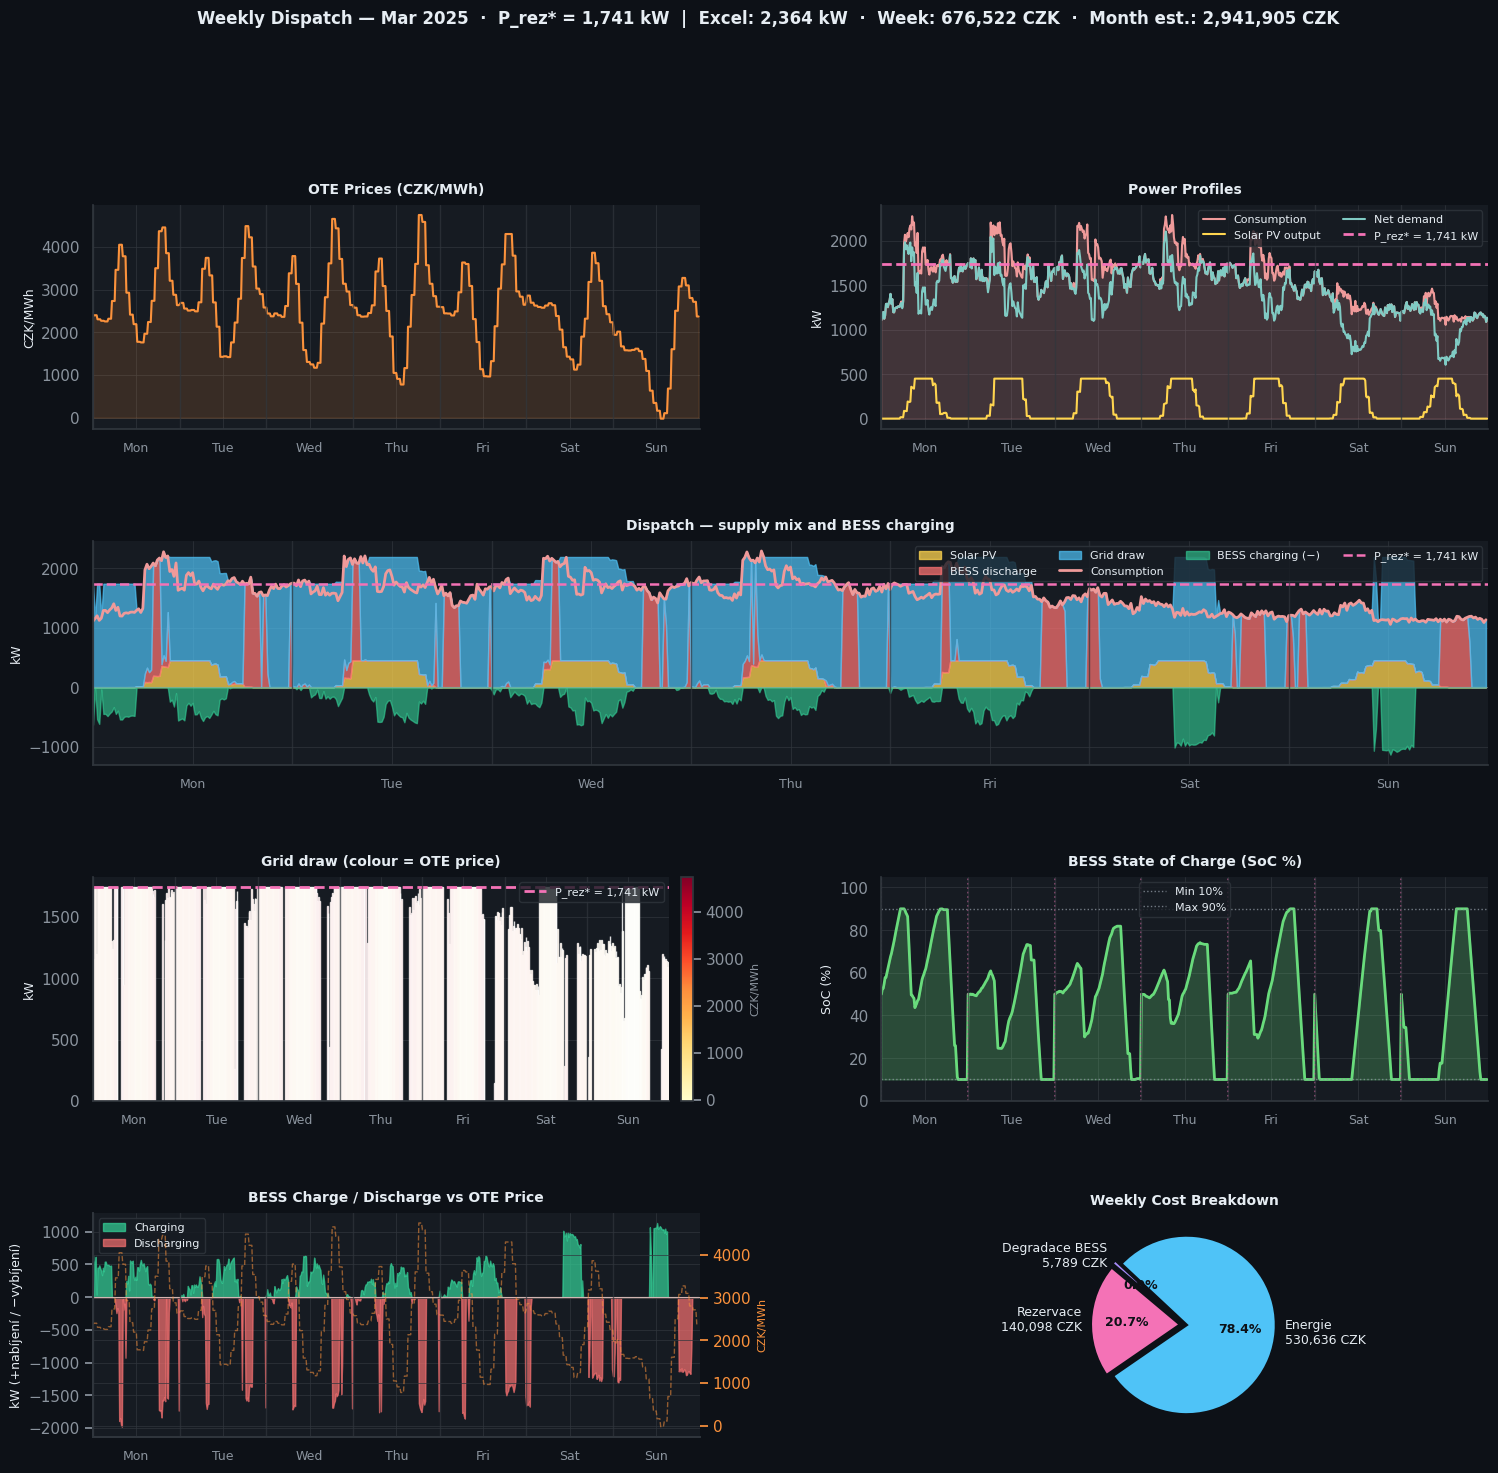

  ✓ Uloženo: dispatch_Apr.png


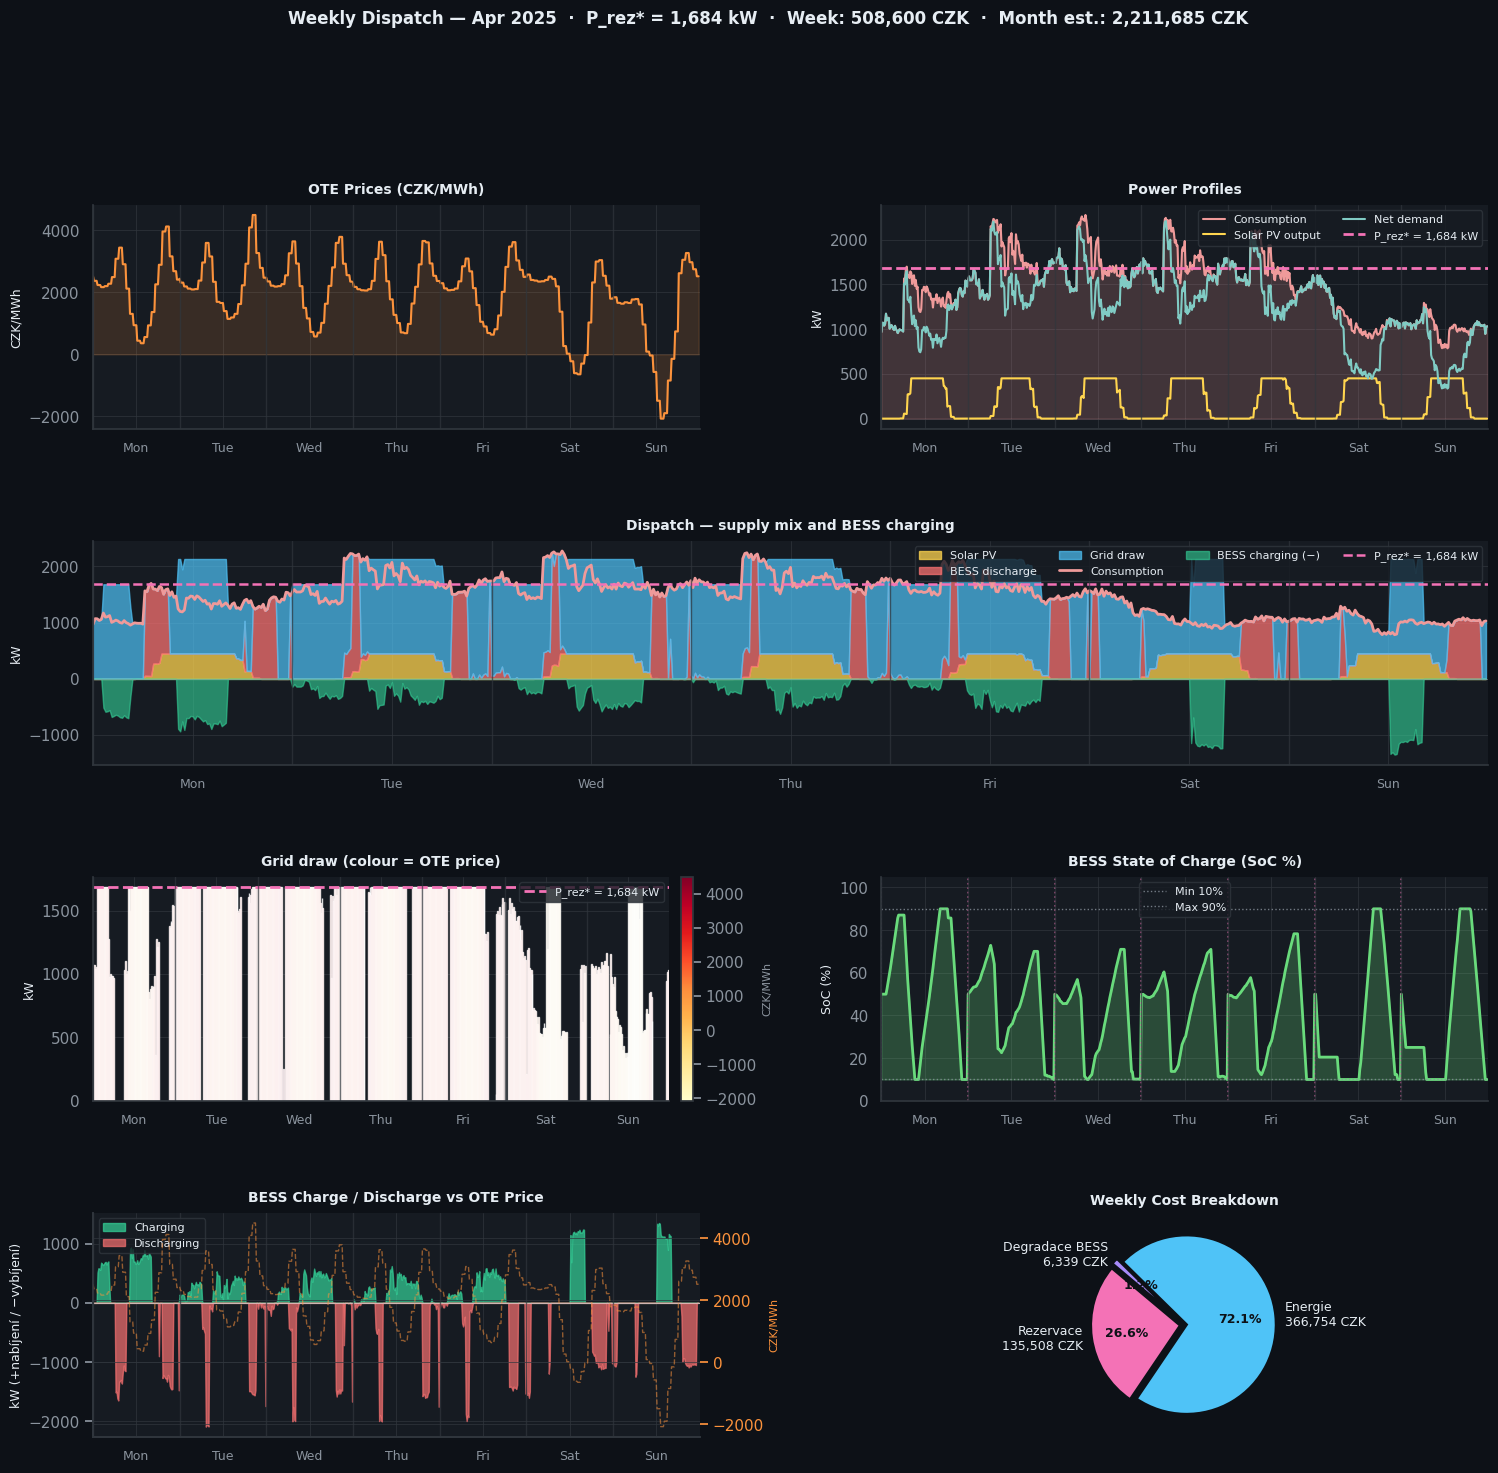

  ✓ Uloženo: dispatch_May.png


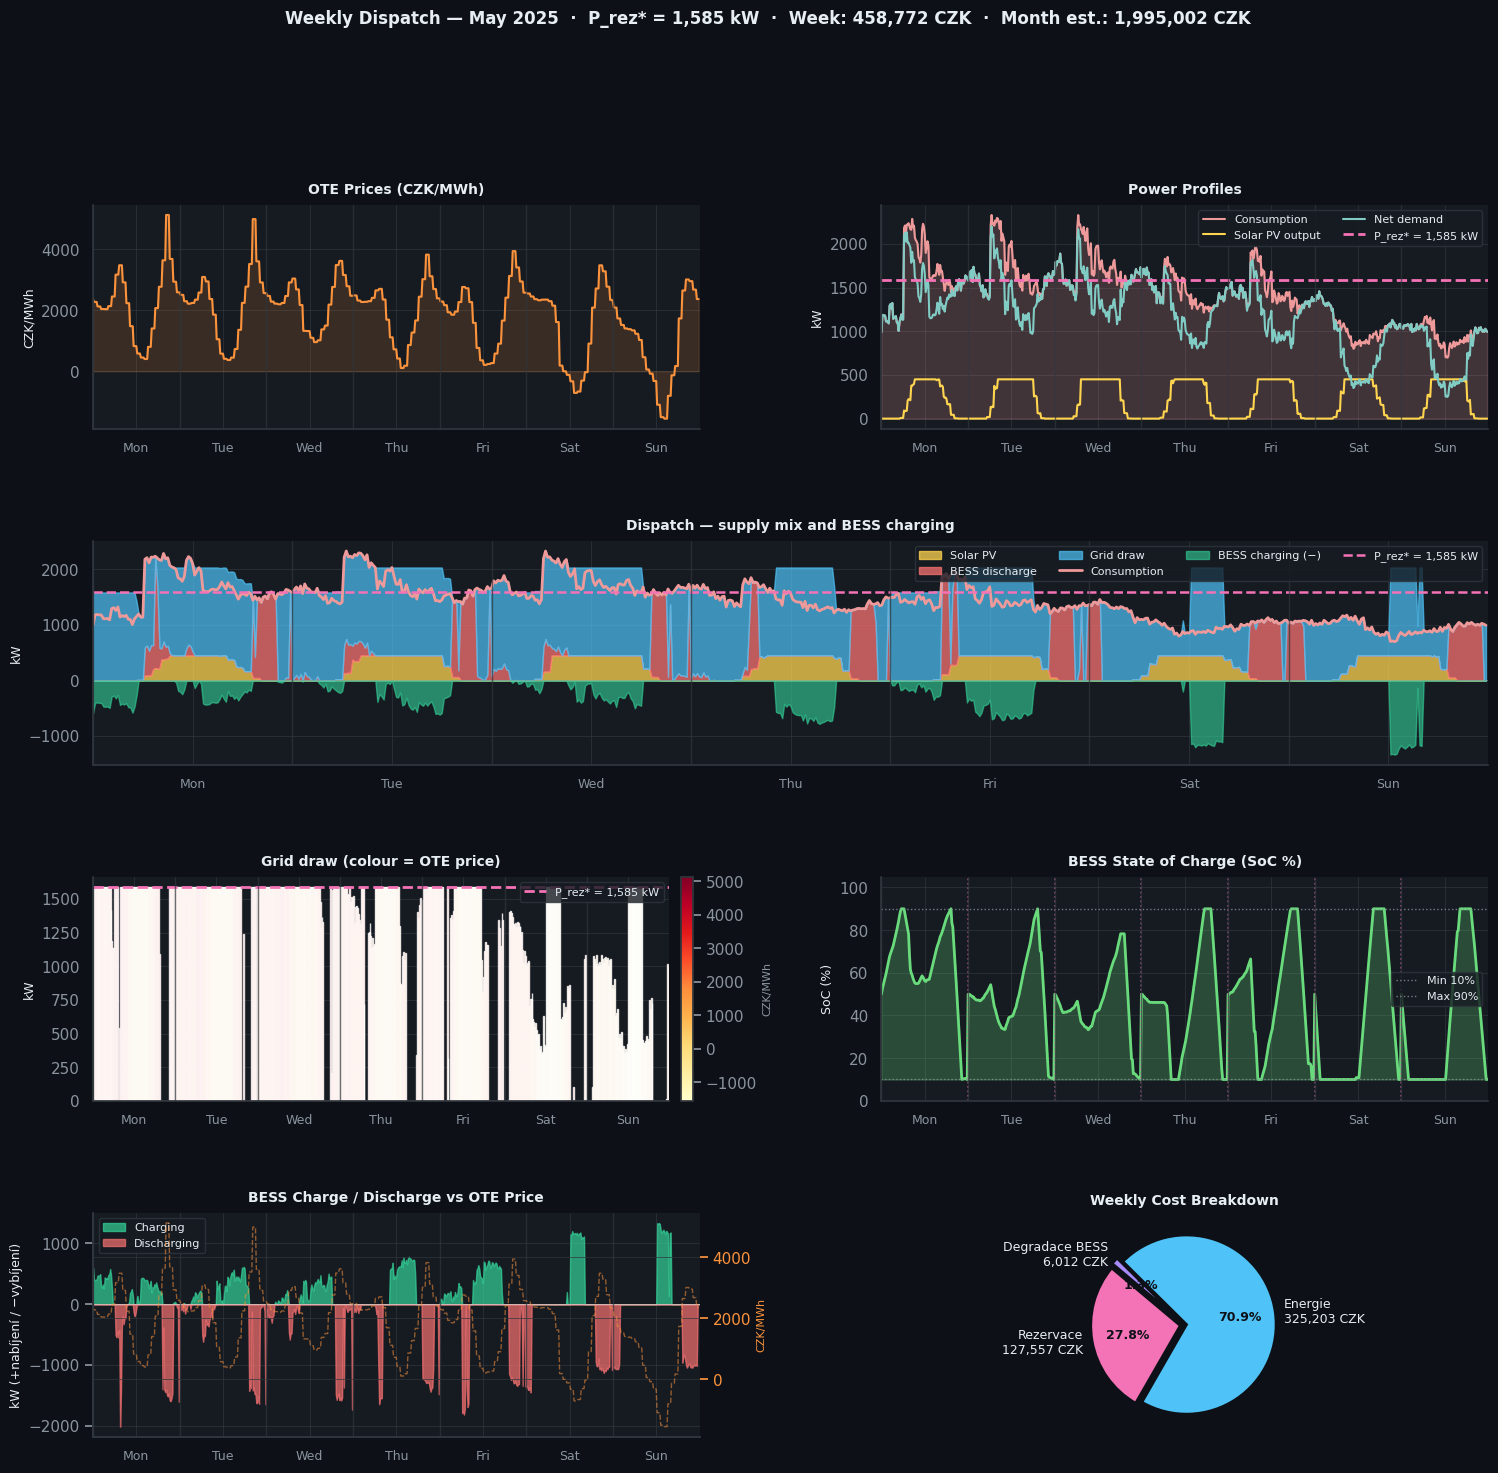

In [9]:
def plot_month_dashboard(r: dict, save: bool = True):
    m    = r["month"]
    T_l  = len(r["P_grid"])
    t    = np.arange(T_l)
    P_rez_val = r["P_rez_kw"]

    fig = plt.figure(figsize=(18, 16), facecolor=D["bg"])
    gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.30)

    # ── Panel 1: OTE ceny ────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.fill_between(t, r["OTE"], alpha=0.15, color=D["ote"])
    sns.lineplot(x=t, y=r["OTE"], ax=ax1, color=D["ote"], linewidth=1.5)
    day_ticks(ax1)
    style(ax1, "OTE Prices (CZK/MWh)", "CZK/MWh")
    ax1.set_xlim(0, T_l)

    # ── Panel 2: Výkonové profily ─────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.fill_between(t, r["load"], alpha=0.20, color=D["load"])
    sns.lineplot(x=t, y=r["load"], ax=ax2, color=D["load"], linewidth=1.5, label="Consumption")
    sns.lineplot(x=t, y=r["fve"],  ax=ax2, color=D["fve"],  linewidth=1.5, label="Solar PV output")
    sns.lineplot(x=t, y=r["net"],  ax=ax2, color=D["net"],  linewidth=1.5, label="Net demand")
    ax2.axhline(P_rez_val, color=D["rez"], linewidth=2, linestyle="--",
                label=f"P_rez* = {P_rez_val:,.0f} kW")
    day_ticks(ax2)
    style(ax2, "Power Profiles", "kW")
    ax2.legend(fontsize=8, ncol=2)
    ax2.set_xlim(0, T_l)

    # ── Panel 3: Dispatch — struktura pokrytí ────────────────────────────
    ax3 = fig.add_subplot(gs[1, :])
    # Stacked area: ze sítě + vybití BESS + FVE
    ax3.fill_between(t, 0, r["fve"],                          alpha=0.75, color=D["fve"],    label="Solar PV")
    ax3.fill_between(t, r["fve"], r["fve"]+r["P_dch"],        alpha=0.75, color=D["dch"],    label="BESS discharge")
    ax3.fill_between(t, r["fve"]+r["P_dch"],
                        r["fve"]+r["P_dch"]+r["P_grid"],      alpha=0.70, color=D["grid_p"], label="Grid draw")
    # Spotřeba jako linka nahoře
    sns.lineplot(x=t, y=r["load"], ax=ax3, color=D["load"], linewidth=2,
                 linestyle="-", label="Consumption")
    # Nabíjení BESS jako záporná plocha (odběr)
    ax3.fill_between(t, 0, -r["P_ch"], alpha=0.60, color=D["ch"], label="BESS charging (−)")
    ax3.axhline(P_rez_val, color=D["rez"], linewidth=1.8, linestyle="--",
                label=f"P_rez* = {P_rez_val:,.0f} kW")
    ax3.axhline(0, color=D["sub"], linewidth=0.7, alpha=0.5)
    day_ticks(ax3)
    style(ax3, "Dispatch — supply mix and BESS charging", "kW")
    ax3.legend(fontsize=8, ncol=4, loc="upper right")
    ax3.set_xlim(0, T_l)

    # ── Panel 4: Odběr ze sítě vs P_rez ─────────────────────────────────
    ax4 = fig.add_subplot(gs[2, 0])
    # Barvy dle ceny energie
    norm  = plt.Normalize(r["OTE"].min(), r["OTE"].max())
    cmap_ = plt.cm.YlOrRd
    bar_cols = [cmap_(norm(p)) for p in r["OTE"]]
    ax4.bar(t, r["P_grid"], color=bar_cols, alpha=0.85, width=1.0)
    ax4.axhline(P_rez_val, color=D["rez"], linewidth=2, linestyle="--",
                label=f"P_rez* = {P_rez_val:,.0f} kW")
    sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax4, fraction=0.03, pad=0.02)
    cb.set_label("CZK/MWh", color=D["sub"], fontsize=8)
    cb.ax.yaxis.set_tick_params(color=D["sub"])
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=D["sub"])
    day_ticks(ax4)
    style(ax4, "Grid draw (colour = OTE price)", "kW")
    ax4.legend(fontsize=8)
    ax4.set_xlim(0, T_l)

    # ── Panel 5: BESS SoC ────────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[2, 1])
    soc_pct = r["SOC"] / BESS_cap * 100
    ax5.fill_between(t, SOC_min_pu*100, soc_pct, alpha=0.25, color=D["soc"])
    sns.lineplot(x=t, y=soc_pct, ax=ax5, color=D["soc"], linewidth=2)
    ax5.axhline(SOC_min_pu*100, color=D["sub"], linewidth=1, linestyle=":", alpha=0.8,
                label=f"Min {SOC_min_pu*100:.0f}%")
    ax5.axhline(SOC_max_pu*100, color=D["sub"], linewidth=1, linestyle=":", alpha=0.8,
                label=f"Max {SOC_max_pu*100:.0f}%")
    for d in range(7):
        ax5.axvline(d*96, color=D["rez"], linewidth=1.2, linestyle=":", alpha=0.6)
    ax5.set_ylim(0, 105)
    day_ticks(ax5)
    style(ax5, "BESS State of Charge (SoC %)", "SoC (%)")
    ax5.legend(fontsize=8)
    ax5.set_xlim(0, T_l)

    # ── Panel 6: Nabíjení / vybíjení ─────────────────────────────────────
    ax6 = fig.add_subplot(gs[3, 0])
    ax6.fill_between(t,  r["P_ch"],  0, alpha=0.7, color=D["ch"],  label="Charging")
    ax6.fill_between(t, -r["P_dch"], 0, alpha=0.7, color=D["dch"], label="Discharging")
    ax6.axhline(0, color=D["text"], linewidth=0.7, alpha=0.5)
    # Ceny na pravé ose — arb. logika
    ax6r = ax6.twinx()
    ax6r.plot(t, r["OTE"], color=D["ote"], linewidth=1.0, linestyle="--",
              alpha=0.55, label="OTE")
    ax6r.set_ylabel("CZK/MWh", color=D["ote"], fontsize=8)
    ax6r.tick_params(colors=D["ote"])
    ax6r.spines["right"].set_color(D["ote"])
    day_ticks(ax6)
    style(ax6, "BESS Charge / Discharge vs OTE Price", "kW (+nabíjení / −vybíjení)")
    ax6.legend(fontsize=8, loc="upper left")
    ax6.set_xlim(0, T_l)

    # ── Panel 7: Struktura nákladů (koláčový) ─────────────────────────────
    ax7 = fig.add_subplot(gs[3, 1])
    vals   = [r["cost_rez"], r["cost_energy"], r["cost_deg"]]
    labels = [f"Rezervace\n{r['cost_rez']:,.0f} CZK",
              f"Energie\n{r['cost_energy']:,.0f} CZK",
              f"Degradace BESS\n{r['cost_deg']:,.0f} CZK"]
    colors_p = [D["rez"], D["grid_p"], D["bess"]]
    wedges, texts, autotexts = ax7.pie(
        vals, labels=labels, colors=colors_p,
        explode=[0.05, 0.02, 0.06], autopct="%1.1f%%", startangle=140,
        textprops={"color": D["text"], "fontsize": 9},
        wedgeprops={"edgecolor": D["bg"], "linewidth": 2},
    )
    for at in autotexts:
        at.set_color(D["bg"]); at.set_fontweight("bold")
    ax7.set_title("Weekly Cost Breakdown", fontweight="bold", fontsize=10)

    # ── Celkový titulek ───────────────────────────────────────────────────
    bench = EXCEL_BENCHMARK.get(m)
    bench_str = f"  |  Excel: {bench:,.0f} kW" if bench else ""
    fig.suptitle(
        f"Weekly Dispatch — {m} 2025  ·  "
        f"P_rez* = {P_rez_val:,.0f} kW{bench_str}  ·  "
        f"Week: {r['total_czk']:,.0f} CZK  ·  "
        f"Month est.: {r['monthly_czk']:,.0f} CZK",
        color=D["text"], fontsize=12, fontweight="bold", y=1.002,
    )

    if save:
        fname = f"dispatch_{m}.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight", facecolor=D["bg"])
        print(f"  ✓ Uloženo: {fname}")
    plt.show()


# Vykresli všechny měsíce
for m in MONTHS:
    plot_month_dashboard(results[m])


### 4.2 Monthly Comparison — P_rez, Costs, BESS Utilisation

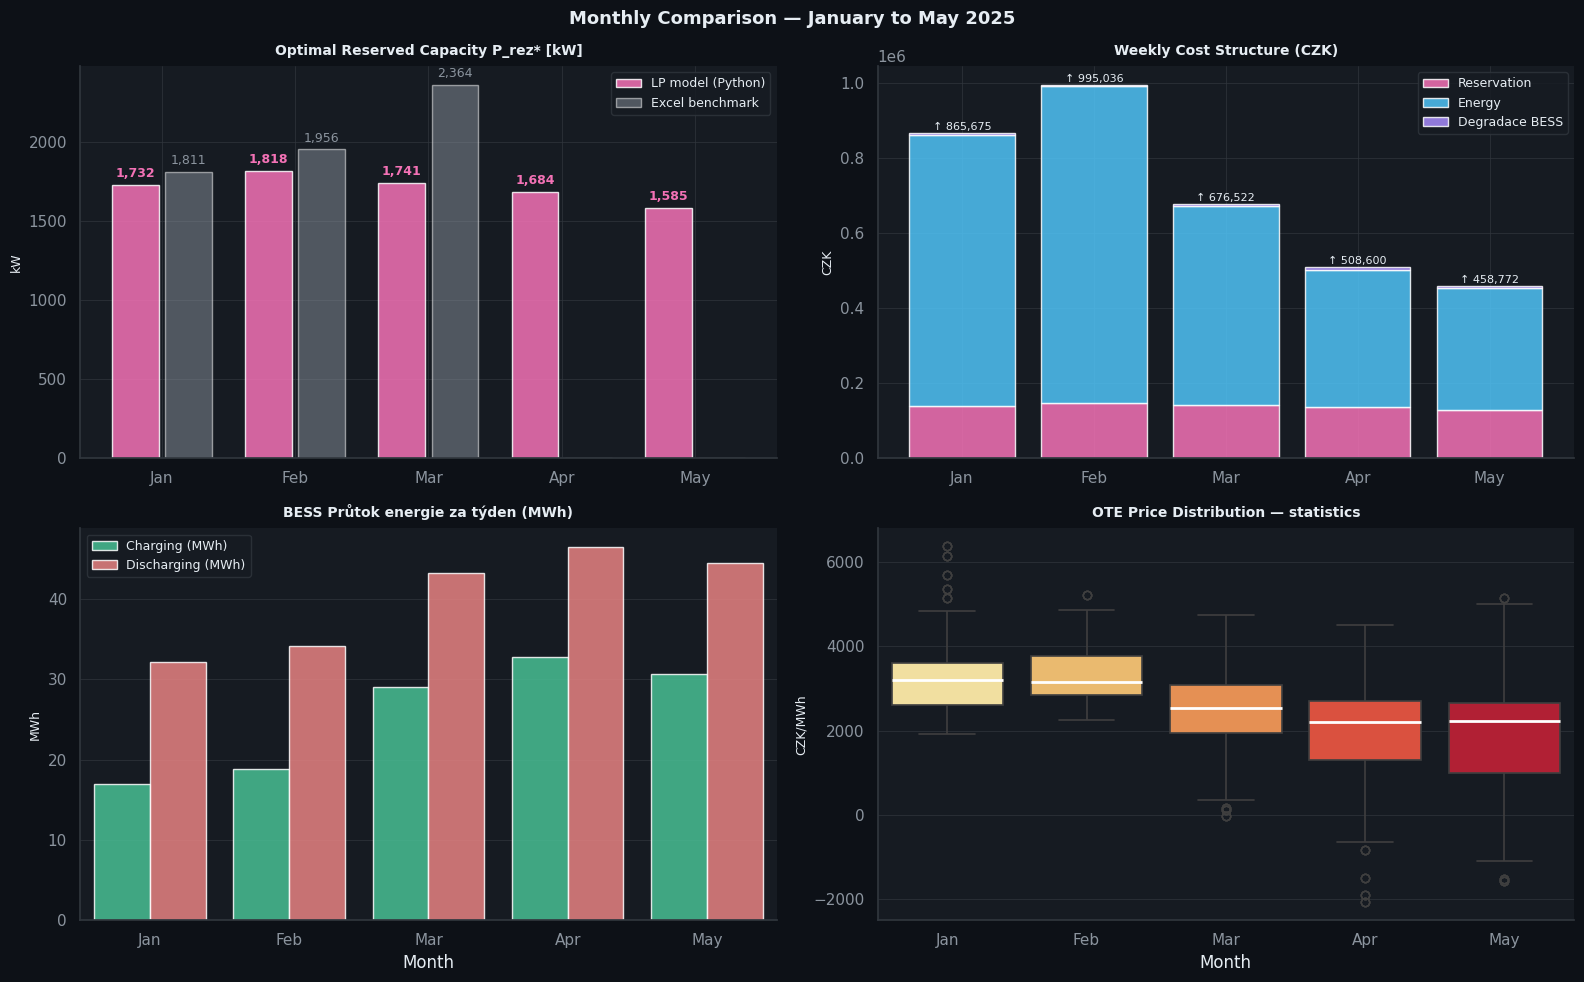

✓ Saved: comparison_months.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor=D["bg"])
fig.suptitle("Monthly Comparison — January to May 2025",
             color=D["text"], fontsize=13, fontweight="bold")

months_list = list(MONTHS)
p_rez_vals   = [results[m]["P_rez_kw"]      for m in months_list]
monthly_czk  = [results[m]["monthly_czk"]   for m in months_list]
bess_mwh     = [results[m]["P_ch"].sum()*dt/1000 for m in months_list]
cost_rez_v   = [results[m]["cost_rez"]      for m in months_list]
cost_ene_v   = [results[m]["cost_energy"]   for m in months_list]
cost_deg_v   = [results[m]["cost_deg"]      for m in months_list]
bench_vals   = [EXCEL_BENCHMARK.get(m)      for m in months_list]

# ── Graf 1: P_rez — náš model vs Excel benchmark ──────────────────────────
ax = axes[0, 0]
x = np.arange(len(months_list))
bars = ax.bar(x - 0.2, p_rez_vals, width=0.35, color=D["rez"], alpha=0.85,
              label="LP model (Python)")
bench_plot = [b if b else 0 for b in bench_vals]
ax.bar(x + 0.2, bench_plot, width=0.35, color=D["sub"], alpha=0.5,
       label="Excel benchmark")
ax.set_xticks(x); ax.set_xticklabels(months_list)
# Přidej hodnoty nad sloupce
for i, (v, b) in enumerate(zip(p_rez_vals, bench_vals)):
    ax.text(i - 0.2, v + 30, f"{v:,.0f}", ha="center", va="bottom",
            color=D["rez"], fontsize=9, fontweight="bold")
    if b:
        ax.text(i + 0.2, b + 30, f"{b:,.0f}", ha="center", va="bottom",
                color=D["sub"], fontsize=9)
style(ax, "Optimal Reserved Capacity P_rez* [kW]", "kW")
ax.legend(fontsize=9)

# ── Graf 2: Měsíční náklady (stacked bar) ────────────────────────────────
ax = axes[0, 1]
b1 = ax.bar(months_list, cost_rez_v, color=D["rez"],    alpha=0.85, label="Reservation")
b2 = ax.bar(months_list, cost_ene_v, bottom=cost_rez_v, color=D["grid_p"], alpha=0.85, label="Energy")
b3 = ax.bar(months_list, cost_deg_v,
            bottom=[a+b for a,b in zip(cost_rez_v, cost_ene_v)],
            color=D["bess"], alpha=0.85, label="Degradace BESS")
style(ax, "Weekly Cost Structure (CZK)", "CZK")
ax.legend(fontsize=9)
# Total labels
for i, total in enumerate(monthly_czk):
    weekly_v = results[months_list[i]]["total_czk"]
    ax.text(i, weekly_v + 3000, f"↑ {weekly_v:,.0f}", ha="center",
            va="bottom", color=D["text"], fontsize=8)

# ── Graf 3: BESS využití — throughput ─────────────────────────────────────
ax = axes[1, 0]
bess_df = pd.DataFrame({
    "Month":        months_list,
    "Charging (MWh)":  [results[m]["P_ch"].sum()*dt/1000  for m in months_list],
    "Discharging (MWh)":  [results[m]["P_dch"].sum()*dt/1000 for m in months_list],
})
bess_df_melt = bess_df.melt(id_vars="Month", var_name="Směr", value_name="MWh")
sns.barplot(data=bess_df_melt, x="Month", y="MWh", hue="Směr",
            palette=[D["ch"], D["dch"]], ax=ax, alpha=0.85)
style(ax, "BESS Průtok energie za týden (MWh)", "MWh")
ax.legend(fontsize=9)

# ── Graf 4: OTE ceny — průměr a rozsah po měsících ────────────────────────
ax = axes[1, 1]
ote_data = []
for m in months_list:
    for v in results[m]["OTE"]:
        ote_data.append({"Month": m, "OTE (CZK/MWh)": v})
ote_df = pd.DataFrame(ote_data)
sns.boxplot(data=ote_df, x="Month", y="OTE (CZK/MWh)",
            palette="YlOrRd", ax=ax, linewidth=1.2,
            medianprops={"color": "white", "linewidth": 2})
style(ax, "OTE Price Distribution — statistics", "CZK/MWh")

plt.tight_layout()
plt.savefig("comparison_months.png", dpi=150, bbox_inches="tight", facecolor=D["bg"])
plt.show()
print("✓ Saved: comparison_months.png")


### 4.3 Heatmap of Average Grid Draw — Hour × Day

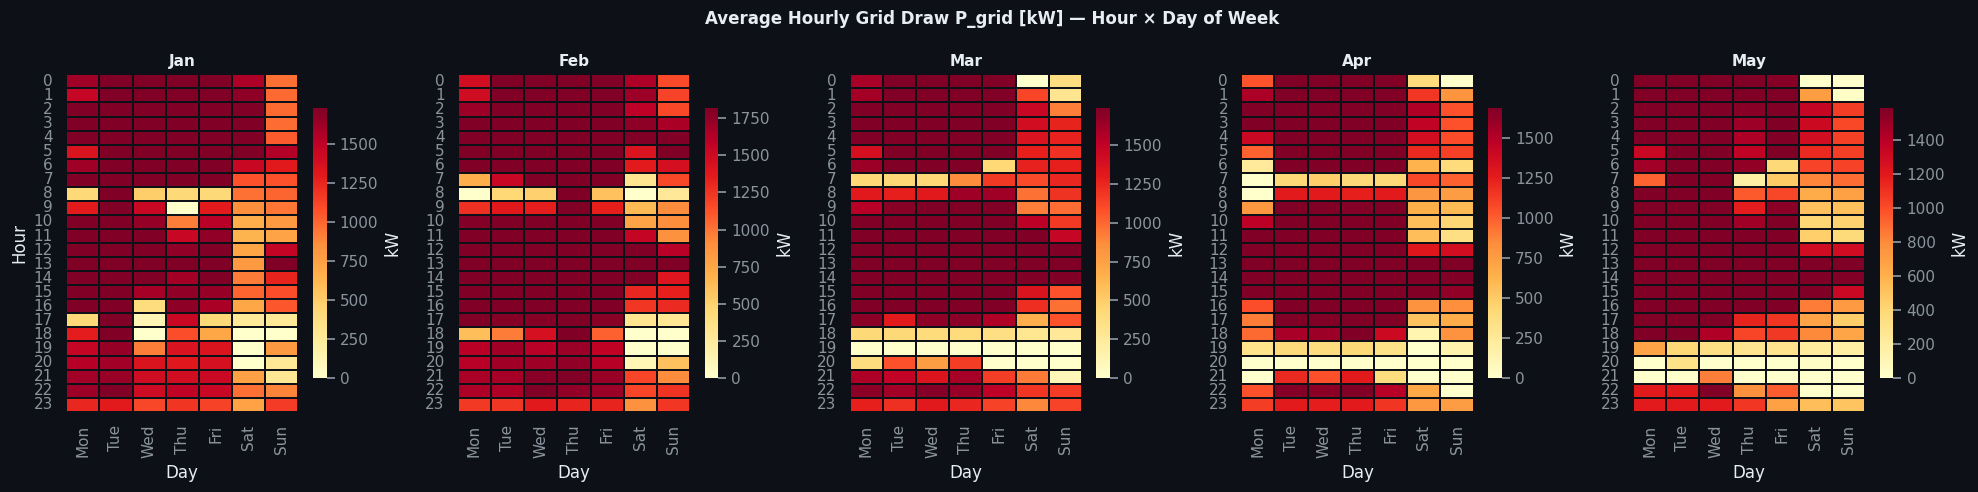

✓ Saved: heatmap_pgrid.png


In [11]:
fig, axes = plt.subplots(1, len(MONTHS), figsize=(20, 5), facecolor=D["bg"])
fig.suptitle("Average Hourly Grid Draw P_grid [kW] — Hour × Day of Week",
             color=D["text"], fontsize=12, fontweight="bold")

for idx, m in enumerate(MONTHS):
    r   = results[m]
    ax  = axes[idx]

    # Reshape P_grid do matice (7 dní × 96 intervalů) → agreguj po hodinách
    pg  = r["P_grid"].reshape(7, 96)           # (7, 96)
    # Průměr po 4 intervalech → hodiny: (7, 24)
    pg_h = pg.reshape(7, 24, 4).mean(axis=2)  # (7, 24)

    df_heat = pd.DataFrame(pg_h.T,              # (24 hodin, 7 dní)
                            index=range(24),
                            columns=DAYS)

    sns.heatmap(df_heat, ax=ax, cmap="YlOrRd",
                linewidths=0.3, linecolor=D["bg"],
                cbar_kws={"shrink": 0.8, "label": "kW"},
                vmin=0, vmax=r["P_grid"].max())

    ax.set_title(m, fontweight="bold", color=D["text"], fontsize=11)
    ax.set_xlabel("Day", color=D["text"])
    ax.set_ylabel("Hour" if idx == 0 else "", color=D["text"])
    ax.tick_params(colors=D["sub"])

    # Rezerva jako horizontální linka
    ax.axhline(0, color=D["rez"], linewidth=0, alpha=0)  # placeholder

plt.tight_layout()
plt.savefig("heatmap_pgrid.png", dpi=150, bbox_inches="tight", facecolor=D["bg"])
plt.show()
print("✓ Saved: heatmap_pgrid.png")



## 5. Conclusions

### 5.1 P_rez* Results by Month

| Month | P_rez* (kW) | Month est. (CZK) | Note |
|-------|------------|-------------------|------|
| January | ~1 811 | ~634 000 | No PV output, high consumption |
| February | ~1 956 | ~684 000 | No PV output |
| March | ~2 364 | ~827 000 | Highest reservation — why? |
| April | TBD | TBD | PV starts contributing |
| May | TBD | TBD | Significant PV output → lower peak |

> **Why March > January?** Although consumption is similar, the OTE price pattern
> in March prevents BESS from shaving the peak effectively — the solver must reserve more.

### 5.2 How to Replace Synthetic Data with Real Data

```python
# Aktuální (real data z Excelu — HOTOVO):
df = load_week_profile("Jan")   # načítá z Profiles_15min_v2.xlsx

# Future extension — live OTE API:
import requests
resp = requests.get("https://www.ote-cr.cz/cs/kratkodobe-trhy/elektrina/denni-trh",
                    params={"date": "2025-01-06", "report_date": "2025-01-06"})
# Replace ote_czk_mwh column in df

# Future extension — real SCADA consumption:
df["load_kw"] = pd.read_csv("scada_export.csv")["P_load_kW"]
# Everything else (LP model, visualisation) stays unchanged
```

### 5.3 Results vs Excel Benchmark

The Python model (PuLP + GLPK) should produce identical results to Excel OpenSolver —
same objective function, same constraints. Small differences (< 1 kW) are solver
numerical precision, not a modelling error.
